<a href="https://colab.research.google.com/github/Ali13fffff/hotel-booking-cancellation-analysis/blob/main/%F0%9F%8F%A8Hotel_booking_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Cancellation Analysis

Hello everyone, my name is Ali. I am a Data Analyst and Data Scientist.

In this project, I will explore and analyze a hotel booking dataset to better understand the factors that contribute to booking cancellations.

Our main objective is to use data-driven insights to help the hotel minimize its cancellation rate and prevent potential revenue leakage.

Throughout this project, we will examine customer behavior, booking characteristics, cancellation patterns, and other relevant factors. The findings will help us develop practical business recommendations for improving hotel revenue and operational efficiency.

Stay with me as we explore the data and uncover valuable insights.✍📊📊

In [1]:

from google.colab import files
uploaded = files.upload()

Saving booking.csv to booking.csv


#Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load The Data

In [3]:
df=pd.read_csv("booking.csv")
print(df.head())
print(df.describe())
print(df.info())

  Booking_ID  number of adults  number of children  number of weekend nights  \
0   INN00001                 1                   1                         2   
1   INN00002                 1                   0                         1   
2   INN00003                 2                   1                         1   
3   INN00004                 1                   0                         0   
4   INN00005                 1                   0                         1   

   number of week nights  type of meal  car parking space    room type  \
0                      5   Meal Plan 1                  0  Room_Type 1   
1                      3  Not Selected                  0  Room_Type 1   
2                      3   Meal Plan 1                  0  Room_Type 1   
3                      2   Meal Plan 1                  0  Room_Type 1   
4                      2  Not Selected                  0  Room_Type 1   

   lead time market segment type  repeated  P-C  P-not-C  average price  \

#Cleaning The Data

In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())
df=df.drop(columns="Booking_ID")

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64
0


## Target Variable Analysis: Booking Status

After loading and cleaning the dataset, we will analyze the target variable, `booking status`.

First, we will examine the number of canceled and non-canceled bookings. This will help us understand the overall cancellation pattern in the dataset.

We will then investigate whether booking cancellations have an impact on the hotel’s potential revenue. This analysis can help us estimate the possible revenue loss caused by cancellations and provide a better understanding of their business impact.

In [11]:

# Create potential revenue column
# Create total number of nights
df['total_nights'] = (
    df['number of weekend nights'] +
    df['number of week nights']
)


df['potential_revenue'] = df['total_nights'] * df['average price']

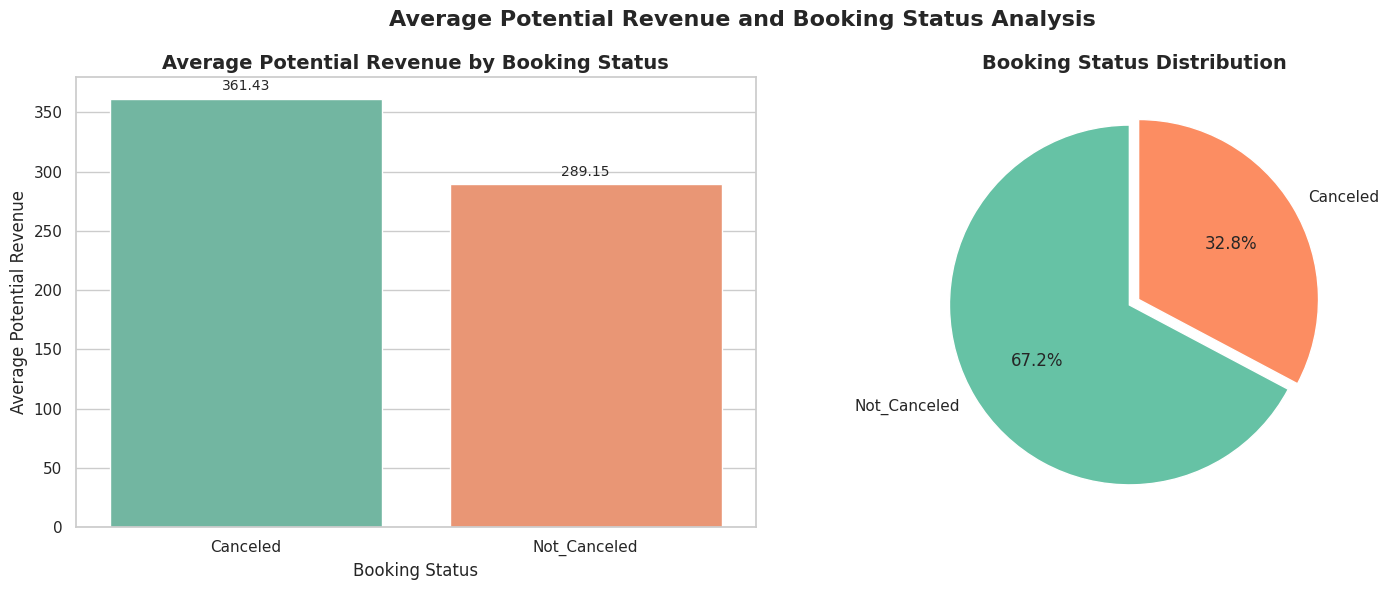

In [12]:


# Calculate average potential revenue by booking status
average_revenue_by_status = (
    df.groupby('booking status')['potential_revenue']
      .mean()
      .sort_values(ascending=False)
)

# Count bookings by booking status
booking_counts = df['booking status'].value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --------------------------------
# 1. Bar Chart: Average Potential Revenue
# --------------------------------
ax1 = axes[0]

sns.barplot(
    x=average_revenue_by_status.index,
    y=average_revenue_by_status.values,
    ax=ax1,
    hue=average_revenue_by_status.index,
    palette='Set2',
    legend=False
)

ax1.set_title(
    'Average Potential Revenue by Booking Status',
    fontsize=14,
    fontweight='bold'
)

ax1.set_xlabel('Booking Status')
ax1.set_ylabel('Average Potential Revenue')

# Add value labels
for i, value in enumerate(average_revenue_by_status.values):
    ax1.text(
        i,
        value + average_revenue_by_status.max() * 0.02,
        f'{value:,.2f}',
        ha='center',
        fontsize=10
    )

# --------------------------------
# 2. Pie Chart: Booking Distribution
# --------------------------------
ax2 = axes[1]

colors = ['#66c2a5', '#fc8d62', '#8da0cb']

ax2.pie(
    booking_counts.values,
    labels=booking_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(booking_counts)],
    explode=[0.03] * len(booking_counts),
    wedgeprops={'edgecolor': 'white'}
)

ax2.set_title(
    'Booking Status Distribution',
    fontsize=14,
    fontweight='bold'
)

# Overall title
plt.suptitle(
    'Average Potential Revenue and Booking Status Analysis',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#Although canceled bookings account for only about 32.8% of all reservations, their average potential revenue is higher than that of not-canceled bookings. This suggests that cancellation is not only a volume issue but also a financial risk issue. In other words, the hotel is losing more valuable reservations, which can lead to a greater revenue impact than the cancellation rate alone implies.

## Temporal Analysis: Reservation Date, Month, and Day-of-Week Cancellation Patterns

In [13]:
# Convert the reservation date column to datetime
df['date of reservation'] = pd.to_datetime(
    df['date of reservation'],
    errors='coerce'
)

# Display the result
df[['date of reservation']].head()

,date of reservation
0,2015-10-02
1,2018-11-06
2,2018-02-28
3,2017-05-20
4,2018-04-11


In [14]:
# Create the day-of-week column
df['reservation_day_of_week'] = (
    df['date of reservation']
      .dt.day_name()
)

# Display the result
df[
    ['date of reservation', 'reservation_day_of_week']
].head()

,date of reservation,reservation_day_of_week
0,2015-10-02,Friday
1,2018-11-06,Tuesday
2,2018-02-28,Wednesday
3,2017-05-20,Saturday
4,2018-04-11,Wednesday


In [15]:
# Ensure the date column is datetime
df['date of reservation'] = pd.to_datetime(df['date of reservation'], errors='coerce')

# Extract day name
df['reservation_day_of_week'] = df['date of reservation'].dt.day_name()

# Create a binary cancellation column if needed
# If your booking status is text like 'Canceled' and 'Not_Canceled':
df['booking_status_number'] = df['booking status'].map({
    'Canceled': 1,
    'Not_Canceled': 0
})

# Group by day of week
day_summary = df.groupby('reservation_day_of_week').agg(
    total_bookings=('booking_status_number', 'count'),
    total_canceled=('booking_status_number', 'sum'),
    cancellation_rate=('booking_status_number', 'mean')
)

# Convert cancellation rate to percentage
day_summary['cancellation_rate'] = day_summary['cancellation_rate'] * 100

# Sort by weekday order
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

day_summary = day_summary.reindex(weekday_order)

day_summary.round(2)

,total_bookings,total_canceled,cancellation_rate
reservation_day_of_week,,,
Monday,5380,1655,30.76
Tuesday,4901,1587,32.38
Wednesday,5123,1681,32.81
Thursday,4545,1430,31.46
Friday,4743,1507,31.77
Saturday,5420,1731,31.94
Sunday,6136,2291,37.34


/tmp/ipykernel_1022/3692581166.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


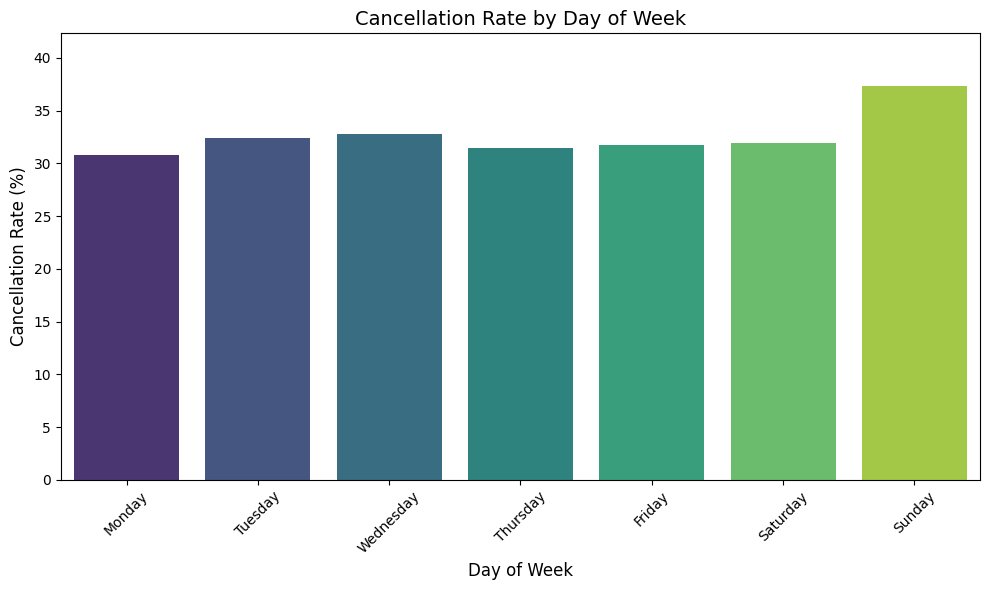

In [ ]:


plt.figure(figsize=(10, 6))
sns.barplot(
    x=day_summary.index,
    y=day_summary['cancellation_rate'],
    palette='viridis'
)

plt.title('Cancellation Rate by Day of Week', fontsize=14)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, day_summary['cancellation_rate'].max() + 5)
plt.tight_layout()
plt.show()

### Key Insights: Reservation Day of Week
* **Finding:** Sunday has the highest cancellation rate at **37.34%** compared to other days of the week.
* **Interpretation:** This represents an initial statistical correlation (signal), not proof of direct causation.
* **Next Steps & Recommendation:** Further multivariate analysis incorporating features such as `lead_time`, `customer_type`, and `deposit_type` is required before implementing any restrictive booking policies on Sundays.

In [ ]:
df['reservation_month'] = df['date of reservation'].dt.month_name()

In [ ]:



month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]


month_summary = df.groupby('reservation_month').agg(
    total_bookings=('booking_status_number', 'count'),
    total_canceled=('booking_status_number', 'sum'),
    cancellation_rate=('booking_status_number', 'mean')
).reindex(month_order)


month_summary['cancellation_rate'] = month_summary['cancellation_rate'] * 100

month_summary

,total_bookings,total_canceled,cancellation_rate
reservation_month,,,
January,1014,24,2.366864
February,1668,424,25.419664
March,2358,700,29.686175
April,2737,996,36.390208
May,2599,949,36.514044
June,3203,1291,40.305963
July,2921,1314,44.984594
August,3813,1488,39.024390
September,4612,1539,33.369471


/tmp/ipykernel_1022/2492228885.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


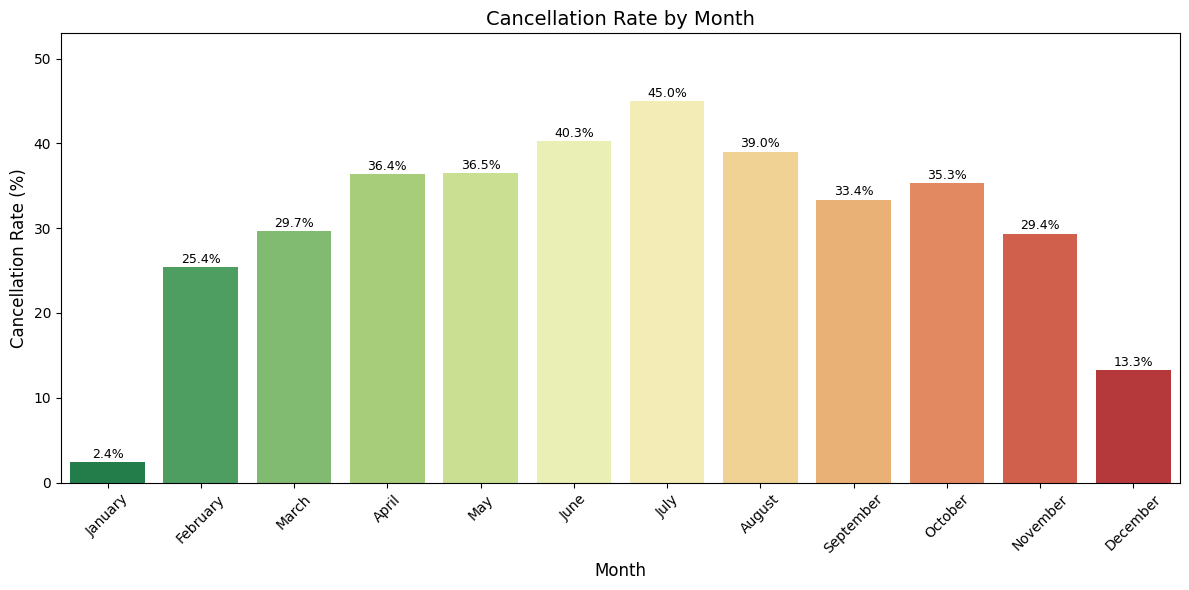

In [ ]:


plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=month_summary.index,
    y=month_summary['cancellation_rate'],
    palette='RdYlGn_r'
)


for i, value in enumerate(month_summary['cancellation_rate']):
    ax.text(i, value + 0.5, f'{value:.1f}%', ha='center', fontsize=9)

plt.title('Cancellation Rate by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, month_summary['cancellation_rate'].max() + 8)
plt.tight_layout()
plt.show()

In [ ]:

monthly_revenue_loss = df[df['booking_status_number'] == 1].groupby('reservation_month')['potential_revenue'].agg(
    total_canceled_bookings='count',
    total_lost_revenue='sum',
    mean_lost_revenue_per_booking='mean'
).reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])


monthly_revenue_loss = monthly_revenue_loss.round(2)
monthly_revenue_loss

,total_canceled_bookings,total_lost_revenue,mean_lost_revenue_per_booking
reservation_month,,,
January,24,4603.10,191.80
February,424,119193.35,281.12
March,700,245020.61,350.03
April,996,328137.92,329.46
May,949,354648.71,373.71
June,1291,440030.57,340.84
July,1314,517431.70,393.78
August,1488,626128.28,420.79
September,1539,608044.67,395.09


/tmp/ipykernel_1022/3613090850.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


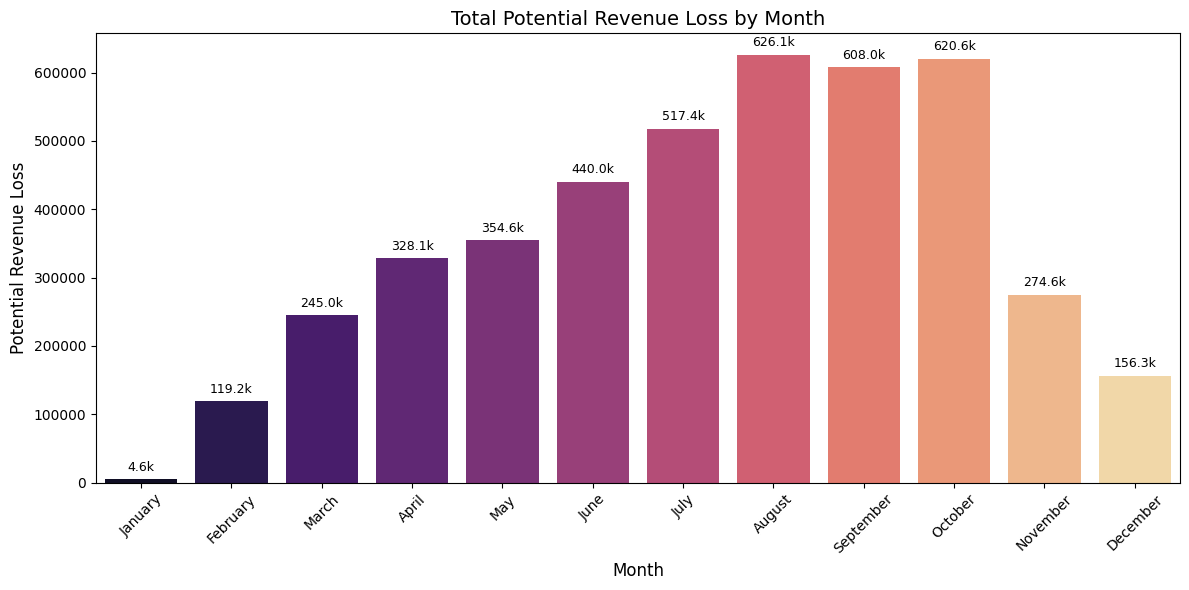

In [ ]:


plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=monthly_revenue_loss.index,
    y=monthly_revenue_loss['total_lost_revenue'],
    palette='magma'
)



for i, value in enumerate(monthly_revenue_loss['total_lost_revenue']):
    ax.text(i, value + (monthly_revenue_loss['total_lost_revenue'].max() * 0.02),
            f'{value/1000:.1f}k', ha='center', fontsize=9, rotation=0)

plt.title('Total Potential Revenue Loss by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Potential Revenue Loss', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Insight: Cancellation Volume vs. Financial Loss

* **Operational Risk:** October has the highest number of canceled bookings, with **1,880 cancellations**. Therefore, it creates the highest operational pressure in terms of capacity planning and inventory management.
* **Financial Risk:** August has the highest total potential revenue loss, equal to **626,128.28**, despite having fewer cancellations than October.
* **Key Explanation:** The average potential revenue per canceled booking is higher in August (**420.79**) than in October (**330.10**).
* **Interpretation:** Cancellation risk should not be evaluated only by cancellation rate or cancellation volume. The financial value of canceled bookings must also be considered.
* **Business Recommendation:** October requires stronger volume and capacity management, while August and July require greater protection for high-value reservations through deposits, non-refundable rates, and targeted confirmation campaigns.
* **Caveat:** `potential_revenue` is an estimate based on `total_nights × average_price`; it does not necessarily represent actual realized revenue or final financial loss.

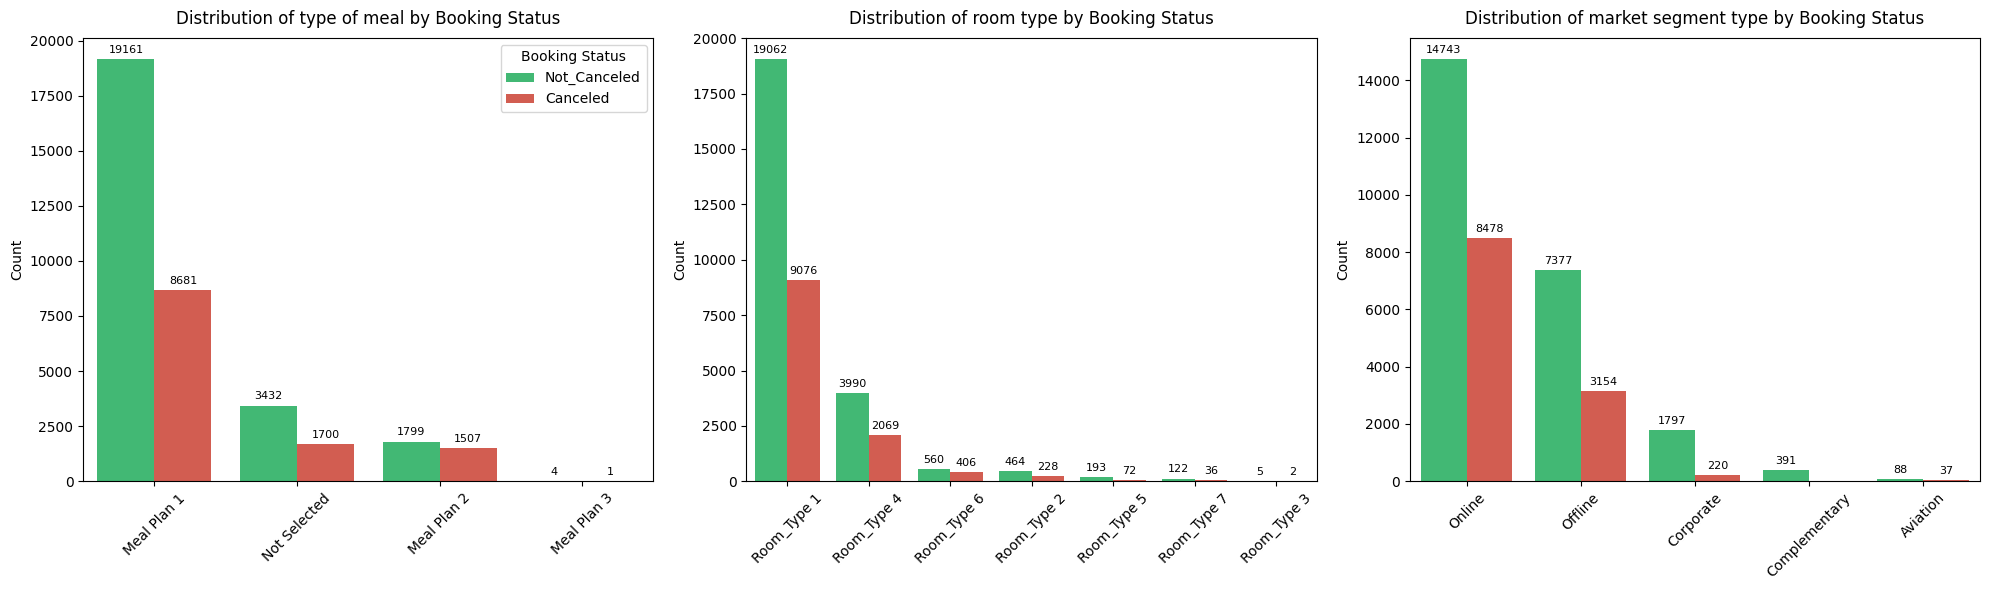

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['type of meal', 'room type', 'market segment type']


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        hue='booking status',
        ax=axes[i],
        palette={'Not_Canceled': '#2ecc71', 'Canceled': '#e74c3c'},
        order=df[col].value_counts().index
    )
    axes[i].set_title(f'Distribution of {col} by Booking Status', fontsize=12, pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)


    for p in axes[i].patches:
        height = p.get_height()
        if not pd.isna(height) and height > 0:
            axes[i].annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=8, xytext=(0, 3),
                textcoords='offset points'
            )


    if i == 0:
        axes[i].legend(title='Booking Status', loc='upper right')
    else:
        axes[i].legend().remove()

plt.tight_layout()
plt.show()

/tmp/ipykernel_1022/1221111243.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_1022/1221111243.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_1022/1221111243.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


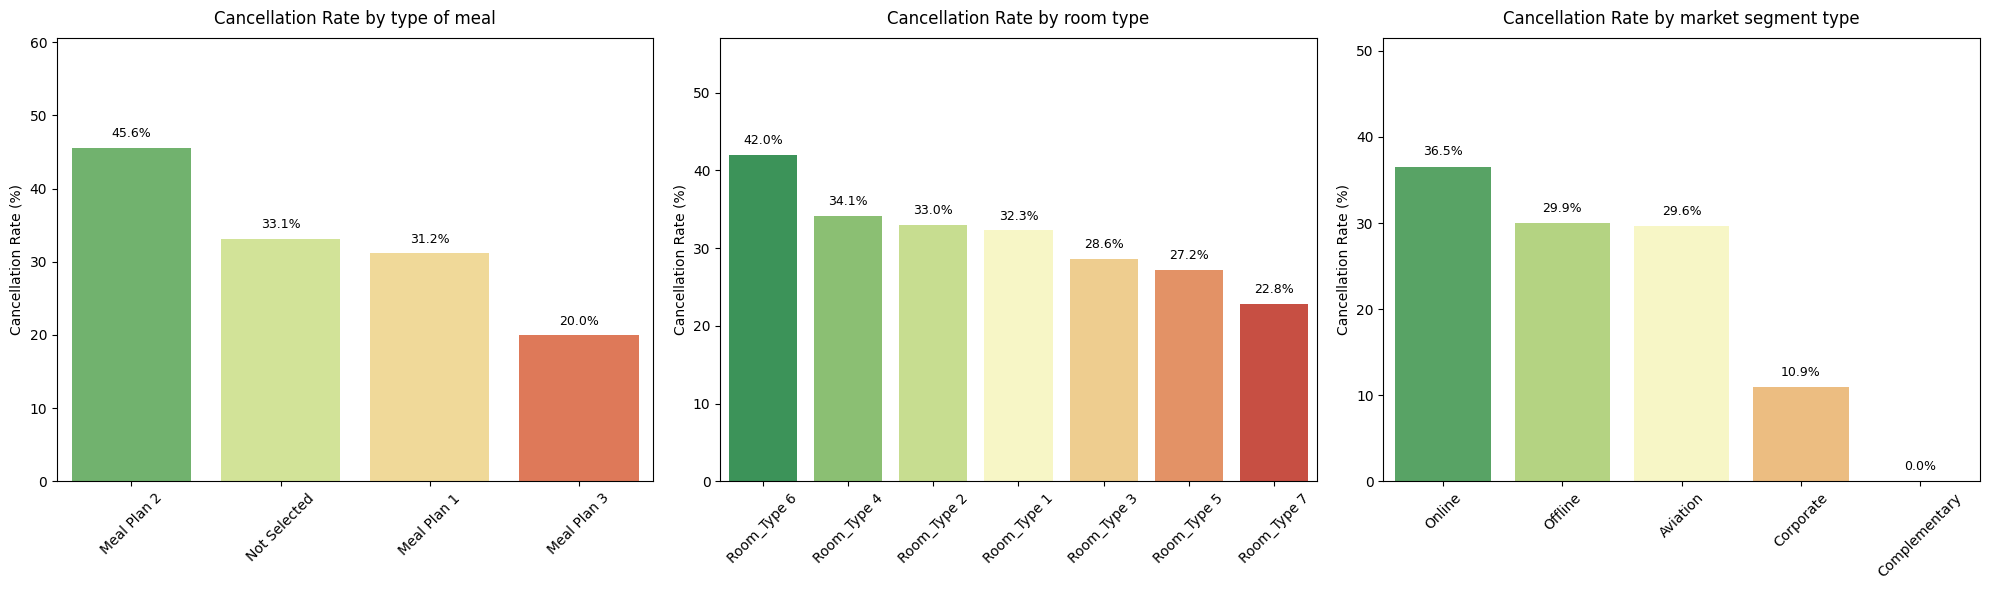

In [ ]:


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(categorical_cols):

    rates = (
        df.groupby(col)['booking_status_number']
          .mean()
          .mul(100)
          .round(2)
          .sort_values(ascending=False)
    )


    ax = axes[i]
    bars = sns.barplot(
        x=rates.index,
        y=rates.values,
        ax=ax,
        palette='RdYlGn_r'
    )

    ax.set_title(f'Cancellation Rate by {col}', fontsize=12, pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Cancellation Rate (%)', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, rates.max() + 15)   # فضای اضافه برای برچسب‌ها


    for bar, val in zip(bars.patches, rates.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            val + 1,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()

## Categorical Analysis Summary

In this section, three categorical columns were analyzed:

- `type of meal`
- `room type`
- `market segment type`

### Main Findings
- `Meal Plan 2` has the highest cancellation rate among meal types.
- `Room_Type 6` has the highest cancellation rate among room types.
- `Online` has the highest cancellation rate among market segments.
- `Complementary` shows the lowest cancellation rate, but its sample size is small.

### Initial Interpretation
These results are only initial statistical signals and do not prove the real cause of cancellations.  
The observed patterns may be influenced by other factors such as `lead_time`, `customer type`, `deposit type`, and `average price`.

### Next Step
These columns should be analyzed together with other variables to identify the stronger factors behind booking cancellations.

#Lead Time and Cancellation Rate Analysis

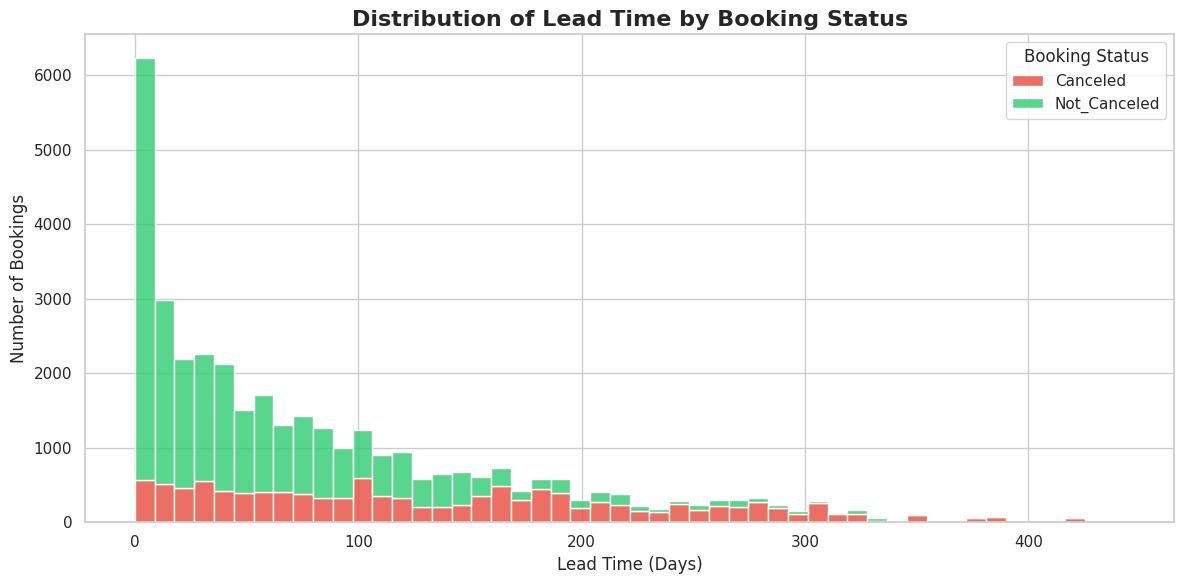

In [8]:

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))


ax = sns.histplot(
    data=df,
    x="lead time",
    hue="booking status",
    multiple="stack",
    palette={"Not_Canceled": "#2ecc71", "Canceled": "#e74c3c"},
    bins=50,
    edgecolor="white",
    alpha=0.8
)

plt.title("Distribution of Lead Time by Booking Status", fontsize=16, fontweight='bold')
plt.xlabel("Lead Time (Days)", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)
plt.legend(title="Booking Status", labels=["Canceled", "Not_Canceled"])
plt.tight_layout()
plt.show()

,lead_time_group,total_bookings,total_canceled,cancellation_rate
0,0-50,"15,569","2,733",17.55%
1,51-100,"7,525","2,105",27.97%
2,101-150,"4,610","1,766",38.31%
3,151-200,"3,159","2,133",67.52%
4,201-300,"3,000","2,169",72.30%
5,301-400,"1,023",813,79.47%
6,+400,102,102,100.00%


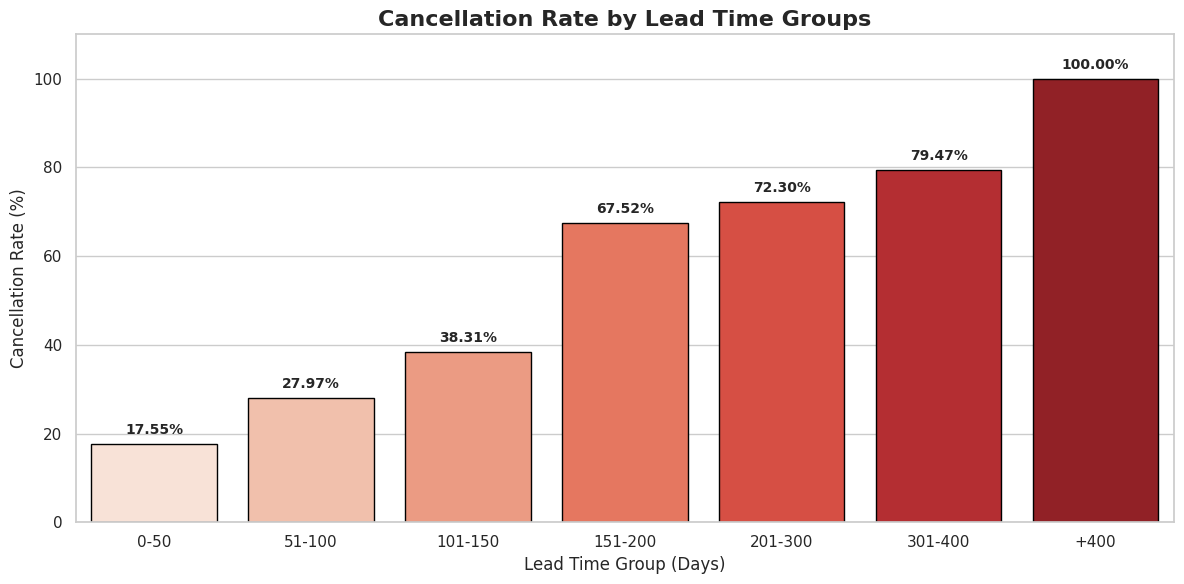

In [20]:



Analysis_Lead_time_group = (
    df.groupby('lead_time_group', observed=False)
      .agg(
          total_bookings=('booking_status_number', 'count'),
          total_canceled=('booking_status_number', 'sum'),
          cancellation_rate=('booking_status_number', 'mean')
      )
      .assign(
          cancellation_rate=lambda x: (
              x['cancellation_rate'] * 100
          ).round(2)
      )
      .reset_index()
)

display(
    Analysis_Lead_time_group.style
        .format({
            'total_bookings': '{:,}',
            'total_canceled': '{:,}',
            'cancellation_rate': '{:.2f}%'
        })
        .background_gradient(
            subset=['cancellation_rate'],
            cmap='Reds'
        )
)

sns.set_theme(style='whitegrid')

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=Analysis_Lead_time_group,
    x='lead_time_group',
    y='cancellation_rate',
    hue='lead_time_group',
    palette='Reds',
    edgecolor='black',
    legend=False
)

plt.title(
    'Cancellation Rate by Lead Time Groups',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Lead Time Group (Days)', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)

for bar in ax.patches:
    height = bar.get_height()

    ax.annotate(
        f'{height:.2f}%',
        xy=(
            bar.get_x() + bar.get_width() / 2,
            height
        ),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0, 110)
plt.tight_layout()
plt.show()

## Lead Time Analysis

`Lead time` shows the number of days between the reservation date and the arrival date.

The distribution of `lead time` is right-skewed. Most bookings were made a short time before arrival, while a smaller number had very long lead times.

The cancellation rate increases as `lead time` becomes longer:

- **0–50 days:** 17.55%
- **101–150 days:** 38.31%
- **151–200 days:** 67.52%
- **301–400 days:** 79.47%
- **+400 days:** 100%

Overall, longer lead times are strongly associated with higher cancellation rates. However, this relationship shows correlation, not causation. Other factors, such as `deposit type`, `customer type`, `market segment type`, and `average price`, may also affect cancellations.

The `+400` group contains only 102 bookings, so its 100% cancellation rate should be interpreted cautiously.